# ResNet summary

## Core problem
Very deep CNNs **should** perform better than shallower ones because they have higher capacity.

But in practice, after some depth:
- training error gets worse
- validation/test error gets worse

This is called **degradation**.

Important:
- this is **not just overfitting**
- the issue is mainly **optimization difficulty**
- gradients become hard to propagate through many layers


## Core idea of ResNet
Instead of forcing a block to learn a full transformation

$y = H(x)$

ResNet makes the block learn a **residual correction**

$y = F(x) + x$

Where:
- \(x\) = input of the residual block
- \(F(x)\) = output of the conv layers inside the block
- \(y\) = output of the residual block

Interpretation:
- normal CNN block: "replace the representation"
- residual block: "keep the representation and refine it"

So:
- if a block needs to change the input, it learns \(F(x)\neq 0\)
- if a block does not need to change much, it can learn \(F(x)\approx 0\)

Then:

$y \approx x$

meaning the block behaves almost like an identity mapping.



## Why this helps
### Forward logic
If the best thing to do is "do almost nothing", then in a plain CNN the block must learn

$H(x)=x$

which is hard.

In ResNet, it only needs to learn

$F(x)=0$

which is much easier.

So ResNet makes "doing nothing" easy.



## Why this helps gradients
Residual block:

$y = F(x) + x$


Derivative wrt the block input:

$\frac{\partial y}{\partial x} = \frac{\partial F(x)}{\partial x} + 1$

The important part is the **+1** coming from the identity shortcut.

This means that in backpropagation the gradient does not only depend on the unstable chain through the conv layers:
- there is also a direct identity path
- the gradient can flow through that shortcut

Very important:
- it is **not** that you choose one path or another
- all contributions are summed
- the identity path gives a stable contribution

So ResNet does **not remove multiplication**, but it creates a safer alternative route for the gradient.



## Residual block structure
Basic residual block:

```text
x
 -> conv
 -> BN
 -> ReLU
 -> conv
 -> BN
 -> + x
 -> ReLU
```

So the block computes:  
	•	a transformed path (F(x))  
	•	a shortcut path carrying (x)  
	•	then sums them  



> # Shape constraint

To sum (F(x)) and (x), they must have the same shape.

So for

$y = F(x) + x$

we need:

$shape(F(x)) = shape(x)$

There are two cases.

> Case 1 — same shape  
If we designed the residual block to return an output y with the same shape as the input of the residual block x, so the block keeps:  
	•	same number of channels  
	•	same spatial resolution  

then we can directly sum them:

$y = F(x) + x$


> Case 2 — **shape changes**  
Sometimes the network:  
	•	halves the spatial resolution  
	•	doubles the number of channels  

Then (x) and (F(x)) cannot be added directly.

So we transform the shortcut path too:

$y = F(x) + W_s x$

where (W_s) is usually a 1x1 convolution with appropriate stride.

This is called a **projection shortcut**.



# Full ResNet architecture logic

A ResNet is built by stacking many residual blocks.

Typical pipeline:  
	1.	input image  
	2.	initial convolution layer  
	3.	max pooling  
	4.	residual block group with same shape  
	5.	residual block group with more channels and lower resolution  
	6.	residual block group with even more channels and lower resolution  
	7.	…  
	8.	global average pooling  
	9.	final fully connected layer  
	10.	softmax / class prediction  

Pattern through the stages:  
	•	channels increase: $(64 \to 128 \to 256 \to 512)$  
	•	spatial size decreases: $(56 \to 28 \to 14 \to 7)$  

Interpretation:  
	•	early stages keep more spatial detail  
	•	deeper stages use richer feature channels  
	•	deeper stages are more semantic and less pixel-local  

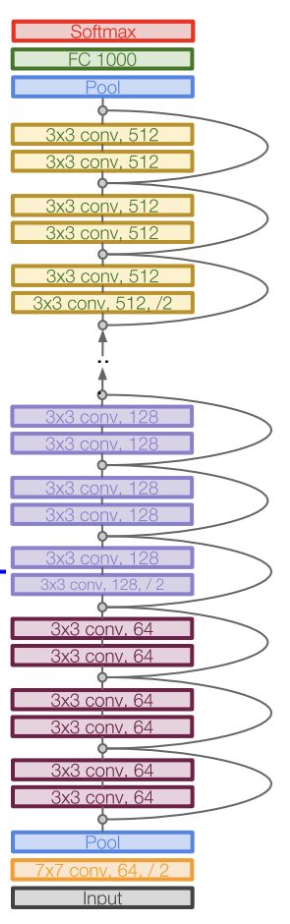

Input image  
↓  
Initial conv layer  
↓  
Pooling  
↓  
Residual blocks (many)  
↓  
Residual blocks (more, deeper, wider)  
↓  
Global average pooling  
↓  
Final classifier (FC)  
↓  
Softmax  

---

> # NN STRUCTURE

#### Beginning
Input: (3, 224, 224)  
↓  
**7×7 conv, 64 filters, stride 2, padding = 0**  
↓  
Output: (64, 112, 112)  
↓  
**MaxPool (3x3, stride 2, padding 1)**  
↓  
Output: (64, 56, 56)  

Why convulation right now?  
- Reduce resolution early → cheaper computation  
- Extract low-level features

---

# First set of residual blocks
> Then we apply **3 residual layers**  
> **Each residual block is composed by 2 convolutional layer**  
> They're all the same convulational layer: **64 channels as input, 64 filters (so 64 channels as output), kernel size 3x3, stride = 1, padding = 1**

#### WTF what sense does it make to apply the same convoloutional layer 6 times????
> They have the SAME STRUCTURE  
> BUT DIFFERENT WEIGHTS  

So each layer is: 3x3 conv, 64
**BUT EACH BLOCK HAS ITS OWN WEIGHTS**

> Block 1 → W1  
> Block 2 → W2  
> Block 3 → W3  

#### Why repeat same structure?
Because we want to progressively refine features  
We perform the same operation type, BUT with different parameters

#### How does the input shape change inside these 3 residual blocks?

$H_{out} = \frac{H_{in} - K + 2P}{S} + 1$

They all have:
- Kernel = 3
- Stride = 1
- Padding = 1

So:
- $H_{out} = \frac{H - 3 + 2(1)}{1} + 1 = \frac{H - 3 + 2}{1} + 1 = H$
- Same for width

So:
- output height = input height
- output width = input width

As a consequence the input is (64, 56, 56)
Each convulation has 3x3, stride=1, padding=1
So after all the 3 residual blocks (3 convoulationl layers) --> the output remains the same: (64, 56, 56)

#### Why are we keeping the same size as the input?
> Remember that each residual block does: $y = F(x) + x$  
> For this to work F(x) and x MUST have same shape

#### Why stack 3 residual blocks?
Each block does a **small correction**  
So by stacking them: x → refine → refine → refine  

What these e residual blocks are doing is: refine features without changing resolution  

This is how residual blocks are usually implemented, you don't put a huge number of layers inside each residual blocks

---

# Second set of residual blocks
- Now we apply 3 different residual blocks
- Each of these 3 residual blocks applies 2 convolutional layers
- Each convolutional layer has:  
      - input channels = 64;  
      - output channels = number of filters = 128;  
      - kernel size = 3x3;  
      - stride = 2;  
      - padding = 1  

#### Dimension check
``` text
      ______________________________
x --> | conv_1 --> conv_2 --> F(x) | --> y = F(x) + x
      |____________________________|
``` 

The input X has dimensions: (64, 56, 56)  
The first residual block output has dimension: $H_{out} = \frac{56 - 3 + 2}{2} + 1 = \frac{55}{2} + 1 = 27.5 + 1 = 28.5 → 28$ --> (128, 28, 28)  
**GODDAMN** --> we cannot compute $y = F(x) + x$ because of the dimension mismatch  

> #### Solution: **projection shortcut**
we transform x --> we pass the input X through a convoulational layer to match F(x) shape:  
- Kernel = 1×1  
- Stride = 2  
- Output channels = 128  

x: (64, 56, 56) → 1×1 conv → (128, 28, 28)  
Now instead of X we'll represent the modified x as: W_s x  

So now we can perform: $y = F(x) + W_s x$  

> So after the first block we have (128, 28, 28)  

#### Rest of the residual blocks?
They're the same as the first one --> now no more shape changes as: 3×3 conv, stride 1, padding 1  
The output of these 3 residual blocks is: (128, 28, 28)  

> we are reducing the resolution (number of pixels) and increase channels (more filter outputs, more feature maps)  

---

# Third set of residual blocks
- 3 residual blocks
- each residualo block has 2 convoloutional layers
- each convoloutional layer has:
    - channel input = 256 (actually 128, but those moron of the lab forgot to add it)
    - channel output = number of filters = 512
    - Kernel = 3×3  
    - Stride = 2  
    - Padding = 1  

Before entering in the 3 last residual blocks we have shape: (256, 14, 14)  

#### Dimension check
$H_{out} = \frac{14 - 3 + 2}{2} + 1 = \frac{13}{2} + 1 = 6.5 + 1 = 7.5 → 7$ --> (512, 7, 7)

Same problem as before, we have:

``` text
      ______________________________
x --> | conv_1 --> conv_2 --> F(x) | --> y = F(x) + x
      |____________________________|
``` 

x : (256, 14, 14)
F(x): (512, 7, 7)

We cannot sum them --> projection shortcut --> pass X thought a convolutional layer with:
- kernel: 1×1
- stride = 2  
- channels = 512

Now: x → (512, 7, 7)  
So we can do: y = F(x) + W_s x  


Last 2 residual blocks keep the now transformed input (512, 7, 7) as it is:
- 3×3 conv, 512, stride 1, padding 1  
- 3×3 conv, 512, stride 1, padding 1

---

# Last part of the NN: pooling + FC + softmax

### Pooling
#### What kind of pooling are we using?
**Global Average Pooling**  
Forces to keep only one value for each channel:  
- we have (512, 7, 7) --> 512 stacke matrixes, each matrix is a 7x7  
- for each of the 512 7x7 matrix compute the average number --> from (512, 7, 7) to (512, 1, 1)  
- so from each channel → we keep 1 number  

> Now we can flatten the image --> 512 x 1 x 1 = 512  

### FC
- Input: (512)  
**Pass it through a fully connected layer that takes input with 512 dimensions --> maps them into outputs with 1000 dimensions**  
- Output: (1000)  

So each input is now associated with 1000 numbers --> 1 number for each class as ImageNet has 1000 classes --> **NOTE: THEY'RE NOT PROBABILITY YET, JUST LOGITS**  
Since fully connected layer do: $y = W x + b$ --> we need to add the bias to each output, so:  
$y = W x + b$
- $x ∈ \mathbb{R}^{512}$
- $W ∈ \mathbb{R}^{1000 × 512}$

#### Softmax
Finally we transform 1000 scores into 1000 probabilities

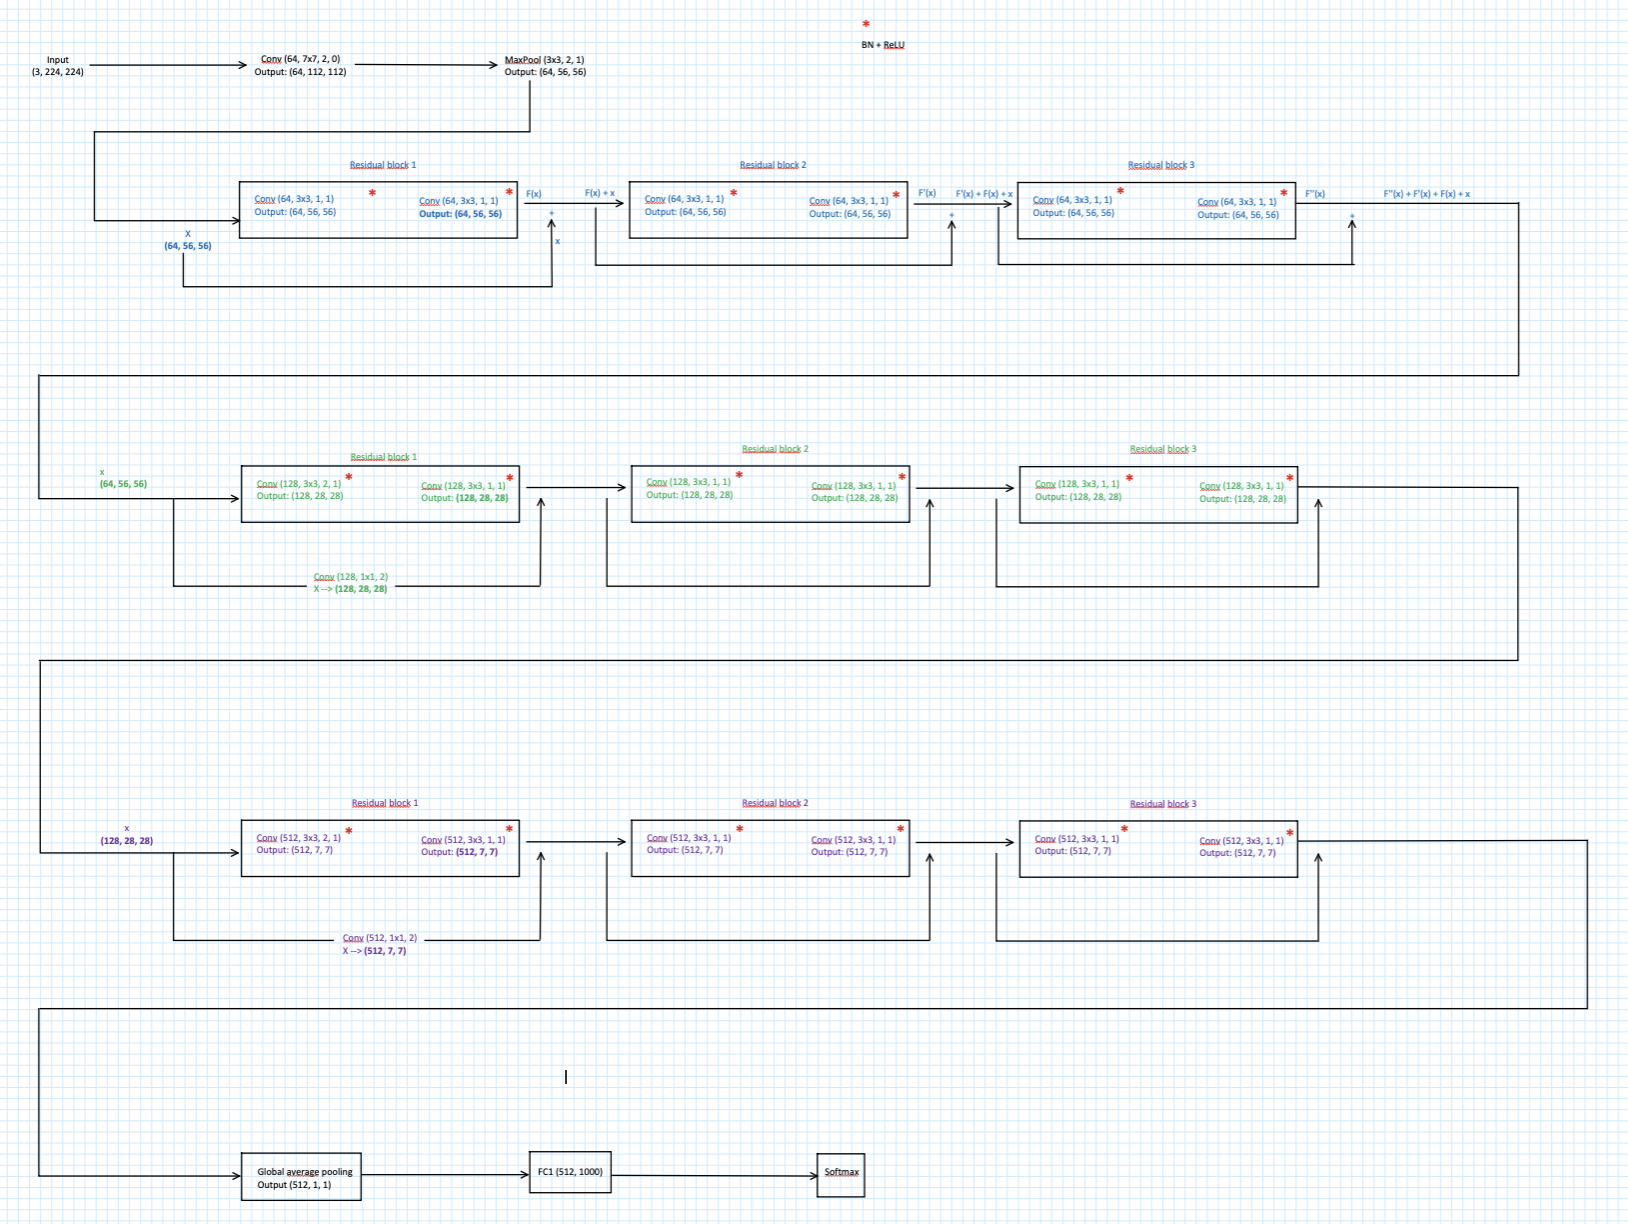

# **NOTE**:
EACH ResNet block actually contains:  
→ Conv  
→ BatchNorm  
→ ReLU  

→ Conv  
→ BatchNorm  
→ Add shortcut  
→ ReLU  

---

---

> # RESIDUAL BLOCK

In [ ]:
import torch
from torch import nn


class ResidualBlock(nn.Module):
    """
    Basic residual block:

    Main path:
        Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN

    Shortcut path:
        - identity if shape does not change
        - 1x1 conv projection if shape changes

    Final:
        out = ReLU(F(x) + shortcut(x))
    """


    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # Main path
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # Shortcut path
        # If dimensions change, project x so that its dimension matches F(x)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x) # immediately fixes X shape if necessary

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


> # ResNet

In [ ]:
class ResNetLite(nn.Module):
    """
    ResNet-style network following the logic of your notes.

    Input image: (3, 224, 224)

    Beginning:
        7x7 conv, 64 filters, stride=2, padding=3 -> (64, 112, 112)
        maxpool 3x3, stride=2, padding=1 -> (64, 56, 56)

    First block group:
        3 residual blocks, channels 64, same resolution
        -> (64, 56, 56)

    Second block group:
        3 residual blocks, first one downsamples and changes channels 64 -> 128
        -> (128, 28, 28)

    Third block group:
        3 residual blocks, first one downsamples and changes channels 128 -> 256
        -> (256, 14, 14)

    Fourth block group:
        3 residual blocks, first one downsamples and changes channels 256 -> 512
        -> (512, 7, 7)

    End:
        Global Average Pooling -> (512, 1, 1)
        Flatten -> (512)
        FC -> (num_classes)
    """
    def __init__(self, num_classes=200):
        super(ResNetLite, self).__init__()

        # beginning
            # Initial convolution layer
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
            # BN + relu
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

            # First maxpool
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )



        # Residual block groups
            # residual block 1
        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1),    # + BN + ReLU applied in the ResidualBlock
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 64, stride=1),
        )

            # residual block 2
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1),
            ResidualBlock(128, 128, stride=1),
        )

            # residual block 3
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1),
            ResidualBlock(256, 256, stride=1),
        )

            # residual block 4
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512, stride=1),
            ResidualBlock(512, 512, stride=1),
        )


        # Final pooling + classifier
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(512, num_classes)

    
    

    def forward(self, x):
        # Beginning
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual block groups:
            # Inside each layer:
                # conv
                # BN
                # ReLU

                # conv
                # BN

                # residual output + x OR W_x (based on shape mismatch)
                # ReLU

        x = self.layer1(x)   # (64, 56, 56)
        x = self.layer2(x)   # (128, 28, 28)
        x = self.layer3(x)   # (256, 14, 14)
        x = self.layer4(x)   # (512, 7, 7)

        # End
        x = self.global_avg_pool(x)   # (512, 1, 1)
        x = self.flatten(x)           # (512)
        x = self.fc(x)                # (200) for TinyImageNet

        return x

---

# Dataset + DataLoader WITH AUGMENTATION

In [ ]:
import os
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader




def get_train_transforms() -> T.Compose:
    """
    Build training preprocessing pipeline with data augmentation.
    """
    transform = T.Compose([
        T.Resize((256, 256)),
        T.RandomResizedCrop((224, 224)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    return transform






def get_eval_transforms() -> T.Compose:
    """
    Build validation/test preprocessing pipeline.
    No data augmentation here.
    """
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    return transform






def build_datasets(data_root: str):
    """
    Build TinyImageNet train/val datasets.

    Expected structure:
    data_root/
        tiny-imagenet-200/
            train/
            val/
    """
    train_transform = get_train_transforms()
    eval_transform = get_eval_transforms()

    train_path = os.path.join(data_root, "tiny-imagenet-200", "train")
    val_path = os.path.join(data_root, "tiny-imagenet-200", "val")

    train_dataset = ImageFolder(root=train_path, transform=train_transform)
    val_dataset = ImageFolder(root=val_path, transform=eval_transform)

    return train_dataset, val_dataset






def build_dataloaders(
    data_root: str,
    batch_size: int = 32,
    num_workers: int = 0,
):
    """
    Build TinyImageNet train/val dataloaders.
    """
    train_dataset, val_dataset = build_datasets(data_root)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, val_loader

---

# evaluation

In [ ]:
def evaluate(model, val_loader, loss_fn, device):
    model.eval()

    val_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            y_predicted = model(x)
            loss = loss_fn(y_predicted, y)

            val_loss += loss.item()
            predictions = y_predicted.argmax(dim=1)
            correct += (predictions == y).sum().item()
            total += y.shape[0]

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100.0 * correct / total

    return val_loss, val_accuracy

---

# train + evaluation + entry point with **manual gridsearch**

In [ ]:
import os
import torch
from torch import nn
import wandb



def train(num_epochs, model, train_loader, val_loader, device, optimizer, loss_fn, save_path):
    best_val_accuracy = 0.0

    for epoch in range(1, num_epochs + 1):
        model.train()

        running_loss = 0.0
        total_correct_predictions = 0
        total_predictions = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            y_predicted = model(x)
            loss = loss_fn(y_predicted, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predictions = y_predicted.argmax(dim=1)
            total_correct_predictions += (predictions == y).sum().item()
            total_predictions += y.shape[0]

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100.0 * total_correct_predictions / total_predictions

        
        
        val_loss, val_accuracy = evaluate(model, val_loader, loss_fn, device)

        
        
        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy
        })

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.6f} | Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.6f} | Val Acc: {val_accuracy:.2f}%"
        )


        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), save_path)
            print(f"Saved best validation model -> {save_path}")

    return best_val_accuracy


# main experiment loop
data_root = "data"
num_workers = 0
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rates = [0.1, 0.001, 0.0001]
batch_sizes = [16, 32, 64]
weight_decays = [0.0, 1e-4, 1e-3]

os.makedirs("checkpoints", exist_ok=True)

for lr in learning_rates:
    for batch_size in batch_sizes:
        for weight_decay in weight_decays:
            run_name = f"resnet_lr{lr}_bs{batch_size}_wd{weight_decay}"

            train_loader, val_loader = build_dataloaders(
                data_root=data_root,
                batch_size=batch_size,
                num_workers=num_workers
            )

            model = ResNetLite(num_classes=200).to(device)
            loss_fn = nn.CrossEntropyLoss()

            optimizer = torch.optim.SGD(
                params=model.parameters(),
                lr=lr,
                momentum=0.9,
                weight_decay=weight_decay
            )

            save_path = f"checkpoints/{run_name}.pth"

            wandb.init(
                project="lab-4-ResNet",
                name=run_name,
                config={
                    "epochs": num_epochs,
                    "batch_size": batch_size,
                    "learning_rate": lr,
                    "weight_decay": weight_decay,
                    "optimizer": "SGD",
                    "momentum": 0.9,
                    "architecture": "ResNetLite",
                    "dataset": "TinyImageNet"
                }
            )

            best_val_accuracy = train(
                num_epochs=num_epochs,
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                device=device,
                optimizer=optimizer,
                loss_fn=loss_fn,
                save_path=save_path
            )

            print(f"Finished run: {run_name} | Best Val Acc: {best_val_accuracy:.2f}%")

            wandb.finish()